# 10 — Frozen Three-Role MVP Final Test

## 这是一次性最终评测

09C已经冻结：

- 产品范围：Labour、Conservative、Liberal Democrat；
- 正式模型：`role_prior_blend_50_50`；
- 角色XGBoost权重：50%；
- 最近100票Party Prior权重：50%；
- 分类阈值：0.50；
- RAG职责：只负责证据检索与解释，不覆盖预测。

本Notebook默认：

```python
RUN_FINAL_TEST = False
```

第一次从头运行只会验证冻结清单、显示最终门槛和运行说明，不读取Test。

确认后手动改为：

```python
RUN_FINAL_TEST = True
```

再从头运行一次，才会揭盲2025–2026 Test。

如果完整结果已经存在，Notebook只加载缓存，不会重新选择模型或制造第二次Test尝试。


## Test时期的政治角色

当前Test日期为2025年至2026年4月。在这一时期：

- Labour是执政党；
- Conservative是主要反对党；
- Liberal Democrat是本MVP选择的较小反对党代表。

角色不是永久写死的政党属性。本次映射只为冻结的Test时期服务。未来大选、执政党变化或产品部署到其他时期时，必须先根据预测日期更新角色。


## 最终Test门槛为什么这样设置

这些门槛在读取Test之前声明：

1. 正式模型整体Macro-F1至少0.60；
2. 至少比Rolling-100基准高0.03；
3. 最差范围内政党Macro-F1至少0.50；
4. 最差年份Macro-F1至少0.50；
5. Brier概率误差不高于0.25；
6. 所有范围内Test行都必须得到预测。

`0.60`代表整体需要明显超过最低可用线；`0.50`继续作为政党和年份子组的最低双类别识别线；`+0.03`要求复杂模型提供实际增量，而不只是极小随机波动。


In [9]:
# 导入最终本地评测所需库；这里没有OpenAI或其他付费API
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()
MODEL_DIR = BASE_DIR / "processed" / "model_v2"
FREEZE_DIR = BASE_DIR / "processed" / "three_role_scope_freeze_v1"
OUTPUT_DIR = BASE_DIR / "processed" / "final_test_three_role_v1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = MODEL_DIR / "model_train_v2.csv"
VALIDATION_PATH = MODEL_DIR / "model_validation_v2.csv"
TEST_PATH = MODEL_DIR / "model_test_v2.csv"
FREEZE_MANIFEST_PATH = FREEZE_DIR / "three_role_model_freeze_manifest_v1.json"

# 安全开关：第一次运行必须保持False
RUN_FINAL_TEST = True

TARGET = "target_binary_support"
PRIMARY_MODEL = "role_prior_blend_50_50"
BASELINE_MODEL = "rolling_100_party_prior"
IN_SCOPE_PARTIES = ["labour", "conservative", "liberal-democrat"]
OUT_OF_SCOPE_PARTIES = ["green"]
EXPECTED_TEST_ROLES = {
    "labour": "governing_party",
    "conservative": "main_opposition",
    "liberal-democrat": "smaller_opposition",
}

EXPECTED_FREEZE_SHA256 = (
    "175a2caaa62756fc0a47545afed76f2b07d233409cee20bafcfeb14d6bddd2fc"
)
TEST_ROLE_MAPPING_START = pd.Timestamp("2024-07-05")
TEST_ROLE_MAPPING_END = pd.Timestamp("2026-04-27")
FINAL_TRAINING_REFERENCE_DATE = pd.Timestamp("2025-01-01")

RANDOM_STATE = 42
TIME_DECAY_HALF_LIFE_YEARS = 2.0
ROLLING_VOTE_COUNT = 100
ROLE_MODEL_WEIGHT = 0.50
RECENT_PRIOR_WEIGHT = 0.50
CLASSIFICATION_THRESHOLD = 0.50

# 最终门槛在Test揭盲之前固定
MIN_FINAL_MACRO_F1 = 0.60
MIN_IMPROVEMENT_OVER_BASELINE = 0.03
MIN_WORST_PARTY_MACRO_F1 = 0.50
MIN_WORST_YEAR_MACRO_F1 = 0.50
MAX_BRIER = 0.25

COMPLETE_RUN_MANIFEST_PATH = OUTPUT_DIR / "final_test_run_manifest_v1.json"

print("Notebook version: 10-frozen-three-role-final-test-v1")
print("RUN_FINAL_TEST:", RUN_FINAL_TEST)
print("API calls: 0")
print("LLM calls: 0")
print("Output directory:", OUTPUT_DIR)


Notebook version: 10-frozen-three-role-final-test-v1
RUN_FINAL_TEST: True
API calls: 0
LLM calls: 0
Output directory: /Users/oooo1/01Course/2_70202Applying/reorganised/processed/final_test_three_role_v1


## 1. 验证09C冻结清单

这里会重新计算冻结配置的SHA-256。只要产品范围、模型、权重、阈值或门槛被修改，哈希就不再匹配，最终Test将停止。


In [10]:
# 读取冻结清单，但此时不读取Test
if not FREEZE_MANIFEST_PATH.exists():
    raise FileNotFoundError(FREEZE_MANIFEST_PATH)

freeze_manifest = json.loads(
    FREEZE_MANIFEST_PATH.read_text(encoding="utf-8")
)

# 09C计算哈希时排除了创建时间和哈希字段本身
stable_freeze_payload = {
    key: value
    for key, value in freeze_manifest.items()
    if key not in {"created_at_utc", "freeze_sha256"}
}
canonical_payload = json.dumps(
    stable_freeze_payload,
    ensure_ascii=False,
    sort_keys=True,
    separators=(",", ":"),
).encode("utf-8")
recomputed_freeze_sha256 = hashlib.sha256(canonical_payload).hexdigest()

freeze_checks = {
    "stored_hash_matches_recomputed": (
        freeze_manifest.get("freeze_sha256") == recomputed_freeze_sha256
    ),
    "expected_hash_matches": (
        recomputed_freeze_sha256 == EXPECTED_FREEZE_SHA256
    ),
    "scope_passed": bool(freeze_manifest.get("scope_model_passes")),
    "primary_model_matches": (
        freeze_manifest.get("primary_model") == PRIMARY_MODEL
    ),
    "parties_match": (
        freeze_manifest.get("in_scope_parties") == IN_SCOPE_PARTIES
    ),
    "role_weight_matches": (
        float(freeze_manifest.get("role_model_weight")) == ROLE_MODEL_WEIGHT
    ),
    "prior_weight_matches": (
        float(freeze_manifest.get("recent_prior_weight"))
        == RECENT_PRIOR_WEIGHT
    ),
    "threshold_matches": (
        float(freeze_manifest.get("classification_threshold"))
        == CLASSIFICATION_THRESHOLD
    ),
    "test_not_previously_loaded_in_freeze": (
        freeze_manifest.get("test_loaded") is False
    ),
}

if not all(freeze_checks.values()):
    raise ValueError(
        "冻结清单校验失败，不应运行最终Test："
        f"{freeze_checks}"
    )

print("Freeze checks:", freeze_checks)
print("Verified freeze SHA-256:", recomputed_freeze_sha256)


Freeze checks: {'stored_hash_matches_recomputed': True, 'expected_hash_matches': True, 'scope_passed': True, 'primary_model_matches': True, 'parties_match': True, 'role_weight_matches': True, 'prior_weight_matches': True, 'threshold_matches': True, 'test_not_previously_loaded_in_freeze': True}
Verified freeze SHA-256: 175a2caaa62756fc0a47545afed76f2b07d233409cee20bafcfeb14d6bddd2fc


## 2. 冻结最终模型实现

该实现与09B保持一致：

- 不读取固定政党名称作为XGBoost特征；
- 使用制度角色、政府背书、议案程序和政策领域；
- 历史投票使用两年半衰期；
- XGBoost参数不改变；
- Party Prior只使用开发数据中每个政党的最后100条有效投票；
- 两个概率固定50/50融合。

最终模型在全部Train＋Validation上训练，但仍保留Green历史作为角色规律训练材料；产品只对三个范围内政党输出和评分。


In [11]:
# 特征与09B完全一致，不包含固定政党名称
ROLE_CATEGORICAL_FEATURES = [
    "party_role",
    "final_object_government_backed",
    "government_backing_known",
    "motion_type",
    "motion_family",
    "policy_domain_primary",
    "role_backing_interaction",
]

ROLE_NUMERIC_FEATURES = [
    "motion_month",
    "total_possible_members",
    "is_governing_party",
    "is_main_opposition",
    "is_opposition_day",
    "is_amendment",
    "is_new_clause",
    "is_financial_motion",
    "policy_domain_count",
]

TARGET_DERIVED_COLUMNS = [
    "target_policy_result",
    "target_policy_stance",
    "target_binary_support",
    "target_policy_stance_score",
    "target_ordinal_provisional",
]


def add_role_features(frame):
    # 复制数据，避免意外修改原始DataFrame
    result = frame.copy()
    result["motion_date"] = pd.to_datetime(result["motion_date"])
    result["role_backing_interaction"] = (
        result["party_role"].fillna("unknown").astype(str)
        + "__"
        + result["final_object_government_backed"]
            .fillna("unknown").astype(str)
    )
    for column in ROLE_CATEGORICAL_FEATURES:
        result[column] = result[column].fillna("__missing__").astype(str)
    for column in ROLE_NUMERIC_FEATURES:
        result[column] = pd.to_numeric(result[column], errors="coerce")
    return result


def make_role_preprocessor():
    # 类别独热编码，数值补缺并缩放
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler(with_mean=False)),
    ])
    return ColumnTransformer([
        ("categorical", categorical_pipeline, ROLE_CATEGORICAL_FEATURES),
        ("numeric", numeric_pipeline, ROLE_NUMERIC_FEATURES),
    ], remainder="drop")


def time_decay_weights(history, reference_date):
    # 两年前记录权重为0.5，四年前为0.25
    age_days = (
        reference_date - history["motion_date"]
    ).dt.days.clip(lower=0)
    age_years = age_days / 365.25
    return np.power(0.5, age_years / TIME_DECAY_HALF_LIFE_YEARS)


def make_role_xgboost():
    # 参数与09和09B一致，最终Test前不再修改
    return XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def smoothed_rate(frame):
    # Beta(1,1)平滑防止概率变成绝对0或1
    return (frame[TARGET].sum() + 1.0) / (len(frame) + 2.0)


def build_recent_party_prior(development):
    # 每个政党只使用开发数据中最近100条有效投票
    recent = (
        development.sort_values("motion_date")
        .groupby("party", group_keys=False)
        .tail(ROLLING_VOTE_COUNT)
    )
    rates = {}
    counts = {}
    for party in IN_SCOPE_PARTIES:
        party_recent = recent[recent["party"] == party]
        if len(party_recent) != ROLLING_VOTE_COUNT:
            raise ValueError(
                f"{party}最近历史不足{ROLLING_VOTE_COUNT}条。"
            )
        rates[party] = float(smoothed_rate(party_recent))
        counts[party] = int(len(party_recent))
    return rates, counts


## 3. 定义最终评价方法

Bootstrap以division为单位抽样，而不是按单行抽样。因为同一个议案对应多个政党记录，按行抽样会错误地把这些相关记录当成完全独立样本。


In [12]:
def safe_roc_auc(y_true, probabilities):
    # 单一类别分组无法计算ROC-AUC
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, probabilities)


def evaluate_probabilities(y_true, probabilities):
    # 固定0.50阈值，同时报告分类和概率指标
    y_true = np.asarray(y_true, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predicted = (probabilities >= CLASSIFICATION_THRESHOLD).astype(int)
    return {
        "rows": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, predicted)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, predicted)
        ),
        "macro_f1": float(f1_score(
            y_true, predicted, average="macro", zero_division=0
        )),
        "support_precision": float(precision_score(
            y_true, predicted, zero_division=0
        )),
        "support_recall": float(recall_score(
            y_true, predicted, zero_division=0
        )),
        "roc_auc": float(safe_roc_auc(y_true, probabilities)),
        "brier": float(brier_score_loss(y_true, probabilities)),
    }


def grouped_metrics(frame, group_columns):
    # 对模型、政党和年份使用相同计算方式
    rows = []
    for keys, group in frame.groupby(group_columns, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        record = dict(zip(group_columns, keys))
        record.update(evaluate_probabilities(
            group[TARGET], group["support_probability"]
        ))
        rows.append(record)
    return pd.DataFrame(rows)


def division_bootstrap_macro_f1(frame, iterations=1000):
    # 整个division一起抽样，保留议案内政党记录的相关性
    rng = np.random.default_rng(RANDOM_STATE)
    divisions = frame["division_key"].drop_duplicates().to_numpy()
    scores = []
    grouped = {key: group for key, group in frame.groupby("division_key")}
    for _ in range(iterations):
        sampled_keys = rng.choice(divisions, size=len(divisions), replace=True)
        sampled = pd.concat(
            [grouped[key] for key in sampled_keys],
            ignore_index=True,
        )
        score = f1_score(
            sampled[TARGET],
            sampled["predicted_support"],
            average="macro",
            zero_division=0,
        )
        scores.append(score)
    return {
        "iterations": int(iterations),
        "ci_95_low": float(np.quantile(scores, 0.025)),
        "ci_95_high": float(np.quantile(scores, 0.975)),
    }


def sha256_for_columns(frame, columns):
    # 使用稳定排序和CSV表示计算数据哈希
    payload = (
        frame[columns]
        .sort_values(columns[:2])
        .to_csv(index=False, lineterminator="\n")
        .encode("utf-8")
    )
    return hashlib.sha256(payload).hexdigest()


## 4. 免费预览与安全停止

保持`RUN_FINAL_TEST=False`时，本单元只确认：

- 冻结哈希有效；
- 模型和门槛没有变化；
- 最终Test尚未执行。

它不会读取Test文件。


In [13]:
final_gate_preview = {
    "primary_model": PRIMARY_MODEL,
    "baseline_model": BASELINE_MODEL,
    "in_scope_parties": IN_SCOPE_PARTIES,
    "role_model_weight": ROLE_MODEL_WEIGHT,
    "recent_prior_weight": RECENT_PRIOR_WEIGHT,
    "classification_threshold": CLASSIFICATION_THRESHOLD,
    "minimum_final_macro_f1": MIN_FINAL_MACRO_F1,
    "minimum_improvement_over_baseline": MIN_IMPROVEMENT_OVER_BASELINE,
    "minimum_worst_party_macro_f1": MIN_WORST_PARTY_MACRO_F1,
    "minimum_worst_year_macro_f1": MIN_WORST_YEAR_MACRO_F1,
    "maximum_brier": MAX_BRIER,
    "expected_freeze_sha256": EXPECTED_FREEZE_SHA256,
}

display(pd.Series(final_gate_preview, name="frozen_value").to_frame())

if COMPLETE_RUN_MANIFEST_PATH.exists():
    existing_run_manifest = json.loads(
        COMPLETE_RUN_MANIFEST_PATH.read_text(encoding="utf-8")
    )
    existing_complete = bool(existing_run_manifest.get("run_complete"))
else:
    existing_run_manifest = None
    existing_complete = False

if not RUN_FINAL_TEST:
    print("Final Test: NOT RUN")
    print("Test file read: False")
    print("完整检查预览已通过；确认后把RUN_FINAL_TEST改为True并从头运行。")
elif existing_complete:
    print("已发现完整最终结果；本次将读取缓存，不会重新运行Test。")
else:
    print("RUN_FINAL_TEST=True：即将执行唯一一次最终Test。")


,frozen_value
primary_model,role_prior_blend_50_50
baseline_model,rolling_100_party_prior
in_scope_parties,"[labour, conservative, liberal-democrat]"
role_model_weight,0.5
recent_prior_weight,0.5
classification_threshold,0.5
minimum_final_macro_f1,0.6
minimum_improvement_over_baseline,0.03
minimum_worst_party_macro_f1,0.5
minimum_worst_year_macro_f1,0.5


RUN_FINAL_TEST=True：即将执行唯一一次最终Test。


## 5. 一次性训练、预测和评分

运行顺序严格分开：

```text
读取Test
→ 立即分离私有标签
→ 删除Test目标字段
→ 训练冻结模型
→ 生成并保存无标签预测
→ 最后才合并私有标签评分
```

如果完整运行清单已经存在，本单元只加载此前结果。


In [14]:
def run_final_test_once():
    # 完整结果存在时只读取缓存，保证逻辑上的一次性评测
    if COMPLETE_RUN_MANIFEST_PATH.exists():
        cached_manifest = json.loads(
            COMPLETE_RUN_MANIFEST_PATH.read_text(encoding="utf-8")
        )
        if cached_manifest.get("run_complete") is True:
            return {
                "run_mode": "loaded_existing_complete_run",
                "manifest": cached_manifest,
                "metrics": pd.read_csv(
                    OUTPUT_DIR / "final_test_model_metrics_v1.csv"
                ),
                "party_metrics": pd.read_csv(
                    OUTPUT_DIR / "final_test_party_metrics_v1.csv"
                ),
                "year_metrics": pd.read_csv(
                    OUTPUT_DIR / "final_test_year_metrics_v1.csv"
                ),
                "scored": pd.read_csv(
                    OUTPUT_DIR / "final_test_scored_predictions_private_v1.csv"
                ),
            }

    # 读取开发数据和最终Test；这一行只会在开关为True时运行
    train = pd.read_csv(TRAIN_PATH)
    validation = pd.read_csv(VALIDATION_PATH)
    raw_test = pd.read_csv(TEST_PATH)

    for frame in (train, validation, raw_test):
        frame["motion_date"] = pd.to_datetime(frame["motion_date"])

    # 防止division跨开发集和Test
    development_divisions = set(train["division_key"]) | set(
        validation["division_key"]
    )
    assert not development_divisions & set(raw_test["division_key"])

    # 立即把标签放入私有表，然后从模型输入中删除全部目标字段
    private_labels = raw_test[[
        "row_id", "division_key", "party", TARGET
    ]].copy()
    private_labels[TARGET] = pd.to_numeric(
        private_labels[TARGET], errors="raise"
    ).astype(int)

    test_features = raw_test.drop(
        columns=[
            column
            for column in TARGET_DERIVED_COLUMNS
            if column in raw_test.columns
        ]
    ).copy()
    assert TARGET not in test_features.columns

    # 只输出冻结的三个政党；Green保留在原Test但不进入产品评测
    test_features = test_features[
        test_features["party"].isin(IN_SCOPE_PARTIES)
    ].copy()
    private_labels = private_labels[
        private_labels["party"].isin(IN_SCOPE_PARTIES)
    ].copy()

    # 验证Test日期和制度角色处于冻结映射范围内
    if test_features["motion_date"].min() < TEST_ROLE_MAPPING_START:
        raise ValueError("Test包含角色映射生效前的记录。")
    if test_features["motion_date"].max() > TEST_ROLE_MAPPING_END:
        raise ValueError("Test超出冻结角色映射截止日期。")

    role_audit = test_features[["party", "party_role"]].drop_duplicates()
    role_audit["expected_role"] = role_audit["party"].map(
        EXPECTED_TEST_ROLES
    )
    role_audit["role_matches"] = role_audit["party_role"].eq(
        role_audit["expected_role"]
    )
    if not role_audit["role_matches"].all():
        raise ValueError(
            "Test政党角色与冻结映射不一致：\n"
            + role_audit.to_string(index=False)
        )

    # 使用全部开发数据重建09B冻结模型
    development = pd.concat([train, validation], ignore_index=True)
    development[TARGET] = pd.to_numeric(
        development[TARGET], errors="raise"
    ).astype(int)
    development = add_role_features(development)
    test_features = add_role_features(test_features)

    preprocessor = make_role_preprocessor()
    development_matrix = preprocessor.fit_transform(development)
    test_matrix = preprocessor.transform(test_features)
    sample_weights = time_decay_weights(
        development, FINAL_TRAINING_REFERENCE_DATE
    )

    role_model = make_role_xgboost()
    role_model.fit(
        development_matrix,
        development[TARGET],
        sample_weight=sample_weights,
    )
    role_probability = role_model.predict_proba(test_matrix)[:, 1]

    prior_rates, prior_counts = build_recent_party_prior(development)
    prior_probability = (
        test_features["party"].map(prior_rates).astype(float).to_numpy()
    )
    blended_probability = (
        ROLE_MODEL_WEIGHT * role_probability
        + RECENT_PRIOR_WEIGHT * prior_probability
    )

    # 先保存不含真实标签的公开预测，再进行任何评分
    public_predictions = test_features[[
        "row_id",
        "division_key",
        "motion_date",
        "party",
        "party_role",
        "motion_title_clean",
        "final_policy_object",
        "motion_family",
        "policy_domain_primary",
    ]].copy()
    public_predictions["role_probability"] = role_probability
    public_predictions["recent_prior_probability"] = prior_probability
    public_predictions["support_probability"] = blended_probability
    public_predictions["predicted_support"] = (
        public_predictions["support_probability"]
        >= CLASSIFICATION_THRESHOLD
    ).astype(int)
    public_predictions["predicted_stance"] = np.where(
        public_predictions["predicted_support"].eq(1),
        "support",
        "oppose",
    )
    public_predictions["prediction_model"] = PRIMARY_MODEL
    public_predictions["freeze_sha256"] = EXPECTED_FREEZE_SHA256

    PUBLIC_PREDICTIONS_PATH = (
        OUTPUT_DIR / "final_test_predictions_public_v1.csv"
    )
    public_predictions.to_csv(PUBLIC_PREDICTIONS_PATH, index=False)

    # 同时保存预先登记的Rolling-100基准概率
    baseline_predictions = public_predictions[[
        "row_id", "division_key", "motion_date", "party", "party_role"
    ]].copy()
    baseline_predictions["support_probability"] = prior_probability
    baseline_predictions["predicted_support"] = (
        prior_probability >= CLASSIFICATION_THRESHOLD
    ).astype(int)
    baseline_predictions["prediction_model"] = BASELINE_MODEL

    # 预测保存完成后才合并私有标签并评分
    primary_scored = public_predictions.merge(
        private_labels,
        on=["row_id", "division_key", "party"],
        how="left",
        validate="one_to_one",
    )
    baseline_scored = baseline_predictions.merge(
        private_labels,
        on=["row_id", "division_key", "party"],
        how="left",
        validate="one_to_one",
    )
    if primary_scored[TARGET].isna().any():
        raise ValueError("部分正式预测未匹配到私有标签。")
    if baseline_scored[TARGET].isna().any():
        raise ValueError("部分基准预测未匹配到私有标签。")

    primary_scored["model"] = PRIMARY_MODEL
    baseline_scored["model"] = BASELINE_MODEL
    scored = pd.concat(
        [primary_scored, baseline_scored], ignore_index=True
    )
    scored["motion_year"] = pd.to_datetime(
        scored["motion_date"]
    ).dt.year

    metrics = grouped_metrics(scored, ["model"])
    party_metrics = grouped_metrics(scored, ["model", "party"])
    year_metrics = grouped_metrics(scored, ["model", "motion_year"])

    metric_index = metrics.set_index("model")
    primary_metrics = metric_index.loc[PRIMARY_MODEL]
    baseline_metrics = metric_index.loc[BASELINE_MODEL]
    primary_party = party_metrics[
        party_metrics["model"] == PRIMARY_MODEL
    ]
    primary_year = year_metrics[
        year_metrics["model"] == PRIMARY_MODEL
    ]

    improvement = float(
        primary_metrics["macro_f1"] - baseline_metrics["macro_f1"]
    )
    worst_party_macro_f1 = float(primary_party["macro_f1"].min())
    worst_year_macro_f1 = float(primary_year["macro_f1"].min())
    prediction_coverage = float(
        public_predictions["support_probability"].notna().mean()
    )

    acceptance_gates = {
        "final_macro_f1_gate": bool(
            primary_metrics["macro_f1"] >= MIN_FINAL_MACRO_F1
        ),
        "baseline_improvement_gate": bool(
            improvement >= MIN_IMPROVEMENT_OVER_BASELINE
        ),
        "worst_party_gate": bool(
            worst_party_macro_f1 >= MIN_WORST_PARTY_MACRO_F1
        ),
        "worst_year_gate": bool(
            worst_year_macro_f1 >= MIN_WORST_YEAR_MACRO_F1
        ),
        "brier_gate": bool(primary_metrics["brier"] <= MAX_BRIER),
        "coverage_gate": bool(prediction_coverage == 1.0),
        "freeze_hash_gate": bool(
            recomputed_freeze_sha256 == EXPECTED_FREEZE_SHA256
        ),
    }
    final_test_passes = all(acceptance_gates.values())

    primary_for_bootstrap = primary_scored.copy()
    bootstrap = division_bootstrap_macro_f1(primary_for_bootstrap)

    # 保存模型、预处理器、先验与私有评分结果
    joblib.dump(
        preprocessor,
        OUTPUT_DIR / "frozen_role_preprocessor_v1.joblib",
    )
    role_model.save_model(
        OUTPUT_DIR / "frozen_role_xgboost_v1.json"
    )
    (OUTPUT_DIR / "frozen_recent_party_prior_v1.json").write_text(
        json.dumps({
            "rates": prior_rates,
            "counts": prior_counts,
            "rolling_vote_count": ROLLING_VOTE_COUNT,
            "smoothing": "Beta(1,1)",
        }, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    scored.to_csv(
        OUTPUT_DIR / "final_test_scored_predictions_private_v1.csv",
        index=False,
    )
    metrics.to_csv(
        OUTPUT_DIR / "final_test_model_metrics_v1.csv", index=False
    )
    party_metrics.to_csv(
        OUTPUT_DIR / "final_test_party_metrics_v1.csv", index=False
    )
    year_metrics.to_csv(
        OUTPUT_DIR / "final_test_year_metrics_v1.csv", index=False
    )

    development_hash = sha256_for_columns(
        development,
        ["row_id", "division_key", TARGET],
    )
    test_feature_hash = sha256_for_columns(
        test_features,
        ["row_id", "division_key", "party", "motion_date"],
    )
    test_label_hash = sha256_for_columns(
        private_labels,
        ["row_id", "division_key", "party", TARGET],
    )

    run_manifest = {
        "notebook_version": "10-frozen-three-role-final-test-v1",
        "completed_at_utc": datetime.now(timezone.utc).isoformat(),
        "run_complete": True,
        "run_mode": "new_final_test_run",
        "freeze_sha256": EXPECTED_FREEZE_SHA256,
        "development_sha256": development_hash,
        "test_features_sha256": test_feature_hash,
        "test_labels_sha256": test_label_hash,
        "primary_model": PRIMARY_MODEL,
        "baseline_model": BASELINE_MODEL,
        "in_scope_parties": IN_SCOPE_PARTIES,
        "out_of_scope_parties": OUT_OF_SCOPE_PARTIES,
        "test_start": str(test_features["motion_date"].min().date()),
        "test_end": str(test_features["motion_date"].max().date()),
        "test_rows": int(len(test_features)),
        "test_divisions": int(test_features["division_key"].nunique()),
        "acceptance_gates": acceptance_gates,
        "final_test_passes": bool(final_test_passes),
        "primary_macro_f1": float(primary_metrics["macro_f1"]),
        "baseline_macro_f1": float(baseline_metrics["macro_f1"]),
        "improvement_over_baseline": improvement,
        "worst_party_macro_f1": worst_party_macro_f1,
        "worst_year_macro_f1": worst_year_macro_f1,
        "primary_brier": float(primary_metrics["brier"]),
        "prediction_coverage": prediction_coverage,
        "bootstrap_macro_f1_ci_95": bootstrap,
        "api_calls": 0,
        "llm_calls": 0,
        "rag_used_for_prediction": False,
        "model_selection_after_test_allowed": False,
    }
    COMPLETE_RUN_MANIFEST_PATH.write_text(
        json.dumps(run_manifest, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    return {
        "run_mode": "new_final_test_run",
        "manifest": run_manifest,
        "metrics": metrics,
        "party_metrics": party_metrics,
        "year_metrics": year_metrics,
        "scored": scored,
    }


final_outputs = run_final_test_once() if RUN_FINAL_TEST else None


## 6. 最终结果可视化

只有在最终Test已经执行或存在完整缓存时才绘图。图表不会改变任何模型决定。


,model,rows,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,roc_auc,brier
0,role_prior_blend_50_50,975,0.808,0.797,0.801,0.801,0.881,0.869,0.170
1,rolling_100_party_prior,975,0.442,0.417,0.408,0.508,0.599,0.518,0.288


,model,party,rows,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,roc_auc,brier
0,role_prior_blend_50_50,conservative,321,0.832,0.862,0.820,0.967,0.784,0.942,0.180
1,role_prior_blend_50_50,labour,354,0.853,0.868,0.839,0.700,0.907,0.951,0.172
2,role_prior_blend_50_50,liberal-democrat,300,0.730,0.502,0.456,0.747,0.964,0.779,0.157
3,rolling_100_party_prior,conservative,321,0.308,0.500,0.236,0.000,0.000,0.500,0.342
4,rolling_100_party_prior,labour,354,0.305,0.500,0.234,0.305,1.000,0.500,0.322
5,rolling_100_party_prior,liberal-democrat,300,0.747,0.500,0.427,0.747,1.000,0.500,0.190


,model,motion_year,rows,accuracy,balanced_accuracy,macro_f1,support_precision,support_recall,roc_auc,brier
0,role_prior_blend_50_50,2025,703,0.789,0.779,0.782,0.777,0.872,0.847,0.179
1,role_prior_blend_50_50,2026,272,0.857,0.846,0.850,0.864,0.901,0.918,0.147
2,rolling_100_party_prior,2025,703,0.455,0.434,0.424,0.509,0.617,0.524,0.286
3,rolling_100_party_prior,2026,272,0.408,0.373,0.367,0.503,0.556,0.503,0.293


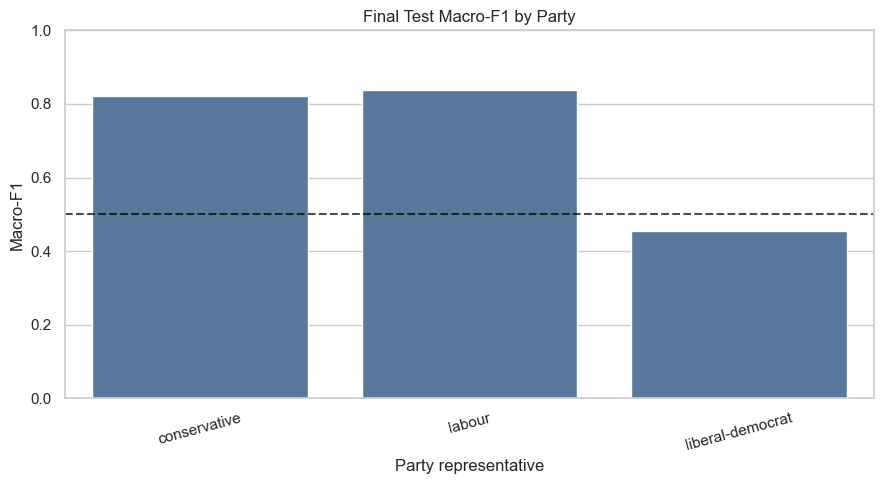

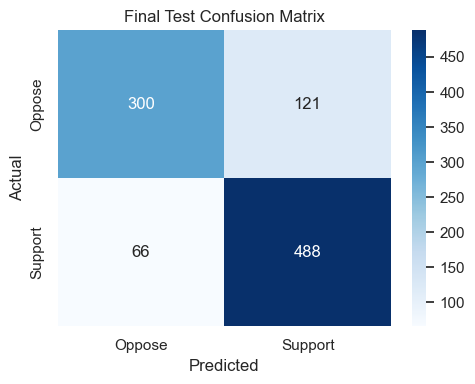

In [15]:
if final_outputs is not None:
    metrics = final_outputs["metrics"]
    party_metrics = final_outputs["party_metrics"]
    year_metrics = final_outputs["year_metrics"]
    scored = final_outputs["scored"]

    display(metrics.round(3))
    display(party_metrics.round(3))
    display(year_metrics.round(3))

    primary_party_plot = party_metrics[
        party_metrics["model"] == PRIMARY_MODEL
    ]
    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=primary_party_plot,
        x="party",
        y="macro_f1",
        color="#4C78A8",
    )
    plt.axhline(
        MIN_WORST_PARTY_MACRO_F1,
        color="black",
        linestyle="--",
        alpha=0.7,
    )
    plt.ylim(0, 1)
    plt.title("Final Test Macro-F1 by Party")
    plt.xlabel("Party representative")
    plt.ylabel("Macro-F1")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "final_test_party_macro_f1_v1.png", dpi=160
    )
    plt.show()

    primary_scored = scored[scored["model"] == PRIMARY_MODEL]
    matrix = confusion_matrix(
        primary_scored[TARGET],
        primary_scored["predicted_support"],
        labels=[0, 1],
    )
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Oppose", "Support"],
        yticklabels=["Oppose", "Support"],
    )
    plt.title("Final Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "final_test_confusion_matrix_v1.png", dpi=160
    )
    plt.show()
else:
    print("RUN_FINAL_TEST=False：没有生成最终结果图。")


## 7. 输出最终审阅摘要

第一次免费预览时会输出`NOT RUN`。改为`True`并完成唯一一次评测后，请把完整摘要复制回来。


In [16]:
if final_outputs is None:
    summary_lines = [
        "=== FROZEN FINAL TEST SUMMARY FOR REVIEW ===",
        "Notebook version: 10-frozen-three-role-final-test-v1",
        f"Freeze SHA-256 verified: {recomputed_freeze_sha256}",
        f"Primary model: {PRIMARY_MODEL}",
        f"Baseline model: {BASELINE_MODEL}",
        f"In-scope parties: {IN_SCOPE_PARTIES}",
        f"Final acceptance thresholds: {final_gate_preview}",
        "RUN_FINAL_TEST: False",
        "Test file read: False",
        "Test result: NOT RUN",
        "Next step: explicitly set RUN_FINAL_TEST=True and run once.",
        f"Output directory: {OUTPUT_DIR}",
        "=== END FROZEN FINAL TEST SUMMARY ===",
    ]
else:
    manifest = final_outputs["manifest"]
    metrics = final_outputs["metrics"].set_index("model")
    primary_metrics = metrics.loc[PRIMARY_MODEL]
    baseline_metrics = metrics.loc[BASELINE_MODEL]
    primary_party = final_outputs["party_metrics"][
        final_outputs["party_metrics"]["model"] == PRIMARY_MODEL
    ]
    primary_year = final_outputs["year_metrics"][
        final_outputs["year_metrics"]["model"] == PRIMARY_MODEL
    ]

    summary_lines = [
        "=== FROZEN FINAL TEST SUMMARY FOR REVIEW ===",
        "Notebook version: 10-frozen-three-role-final-test-v1",
        f"Run mode: {final_outputs['run_mode']}",
        f"Freeze SHA-256 verified: {recomputed_freeze_sha256}",
        f"Test period: {manifest['test_start']} to {manifest['test_end']}",
        f"Test rows: {manifest['test_rows']}",
        f"Test divisions: {manifest['test_divisions']}",
        f"Primary model: {PRIMARY_MODEL}",
        f"Primary Macro-F1: {primary_metrics['macro_f1']:.3f}",
        f"Primary Accuracy: {primary_metrics['accuracy']:.3f}",
        f"Primary ROC-AUC: {primary_metrics['roc_auc']:.3f}",
        f"Primary Brier: {primary_metrics['brier']:.3f}",
        f"Baseline Macro-F1: {baseline_metrics['macro_f1']:.3f}",
        f"Improvement over baseline: "
        f"{manifest['improvement_over_baseline']:.3f}",
        f"Worst-party Macro-F1: {manifest['worst_party_macro_f1']:.3f}",
        f"Worst-year Macro-F1: {manifest['worst_year_macro_f1']:.3f}",
        f"Division-bootstrap Macro-F1 95% CI: "
        f"[{manifest['bootstrap_macro_f1_ci_95']['ci_95_low']:.3f}, "
        f"{manifest['bootstrap_macro_f1_ci_95']['ci_95_high']:.3f}]",
        f"Acceptance gates: {manifest['acceptance_gates']}",
        f"Final Test passes: {manifest['final_test_passes']}",
        "Primary party metrics:",
        primary_party[[
            "party", "rows", "macro_f1", "accuracy", "roc_auc", "brier"
        ]].round(3).to_string(index=False),
        "Primary year metrics:",
        primary_year[[
            "motion_year", "rows", "macro_f1", "accuracy", "roc_auc", "brier"
        ]].round(3).to_string(index=False),
        "RUN_FINAL_TEST: True",
        "Model reselection after Test: NOT ALLOWED",
        "API calls: 0",
        "LLM calls: 0",
        f"Output directory: {OUTPUT_DIR}",
        "=== END FROZEN FINAL TEST SUMMARY ===",
    ]

summary_text = "\n".join(summary_lines)
print(summary_text)
(OUTPUT_DIR / "frozen_final_test_summary_v1.txt").write_text(
    summary_text, encoding="utf-8"
)


=== FROZEN FINAL TEST SUMMARY FOR REVIEW ===
Notebook version: 10-frozen-three-role-final-test-v1
Run mode: new_final_test_run
Freeze SHA-256 verified: 175a2caaa62756fc0a47545afed76f2b07d233409cee20bafcfeb14d6bddd2fc
Test period: 2025-01-14 to 2026-04-27
Test rows: 975
Test divisions: 354
Primary model: role_prior_blend_50_50
Primary Macro-F1: 0.801
Primary Accuracy: 0.808
Primary ROC-AUC: 0.869
Primary Brier: 0.170
Baseline Macro-F1: 0.408
Improvement over baseline: 0.393
Worst-party Macro-F1: 0.456
Worst-year Macro-F1: 0.782
Division-bootstrap Macro-F1 95% CI: [0.772, 0.828]
Acceptance gates: {'final_macro_f1_gate': True, 'baseline_improvement_gate': True, 'worst_party_gate': False, 'worst_year_gate': True, 'brier_gate': True, 'coverage_gate': True, 'freeze_hash_gate': True}
Final Test passes: False
Primary party metrics:
           party  rows  macro_f1  accuracy  roc_auc  brier
    conservative   321     0.820     0.832    0.942  0.180
          labour   354     0.839     0.853    

1488